# QUBO-Inspired Portfolio Optimization with Sector and Budget Constraints

This notebook implements Version 1 (V1) (Update: V2 and V3 too) of a binary portfolio optimization system, focusing on an objective function and a cardinality constraint. It is designed to be mathematically transparent and verifiable.

### ***Disclaimer*** : Note on QUBO Representation

The formulation is QUBO-inspired rather than a fully explicit QUBO compilation. While the return, variance, and cardinality terms are naturally quadratic, sector and budget constraints are implemented through soft penalty functions. Explicit conversion into a static Q-matrix with auxiliary slack variables is deferred to future work.

# Project Overview and Development Journey


This project explores portfolio optimization through a progressively refined QUBO-inspired formulation. Rather than attempting to build a complex model from the outset, the system was developed incrementally, with each iteration introducing an additional practical constraint commonly encountered in real-world portfolio construction.

The project began with a classical mean-variance portfolio optimization framework inspired by Modern Portfolio Theory. The objective was to maximize expected return while minimizing portfolio risk, represented by the covariance matrix of asset returns. To maintain a manageable and interpretable portfolio, a cardinality constraint was introduced, restricting the optimizer to selecting exactly six assets from a universe of twenty stocks.

This initial formulation constituted **Version 1 (V1)**. The optimization objective combined expected return, portfolio variance, and a cardinality penalty term. Exhaustive enumeration over all feasible six-stock portfolios was used to identify the minimum-energy configuration.

After validating the basic optimizer, attention shifted toward practical diversification concerns. A portfolio containing six stocks can still be heavily concentrated within a single industry, creating sector-specific risk. To address this issue, **Version 2 (V2)** introduced a sector diversification constraint. Stocks were grouped into four sectors: Technology, Finance, Healthcare, and Industrial/Energy. A soft quadratic penalty was applied whenever the number of selected assets from a sector exceeded a predefined cap. This encouraged diversification without making the optimization infeasible.

Once sector diversification had been incorporated, the next challenge was portfolio affordability. In real investment scenarios, investors operate under limited capital and cannot arbitrarily select expensive combinations of assets. To model this consideration, **Version 3 (V3)** introduced a budget constraint. Each stock was assigned a fixed representative price, and a quadratic penalty was applied whenever the total portfolio cost exceeded a predefined budget threshold. Experimental results demonstrated that even a relatively small budget penalty coefficient was sufficient to enforce budget-feasible portfolio selection.

To evaluate the behavior of the proposed formulation, a series of parameter sweeps were conducted over the risk-aversion coefficient (λ), sector penalty coefficient (β), and budget penalty coefficient (γ). Additional stress tests were designed to verify that the diversification and budget constraints activated correctly under controlled conditions.

Finally, the proposed discrete constraint-aware optimizer was benchmarked against a classical continuous **Markowitz portfolio optimization** baseline. The comparison highlighted the trade-off between unconstrained continuous allocation and practical discrete portfolio construction. While the Markowitz solution concentrated capital into a small number of assets, the proposed formulation enforced explicit cardinality, diversification, and budget requirements, producing portfolios that more closely resemble realistic investment decisions.

The final system therefore represents a progression from a classical mean-variance optimizer to a constraint-aware portfolio selection framework capable of incorporating practical investment considerations while remaining computationally transparent and interpretable.


# Section 1: Imports
## Importing the necessary libs
We need:-
- numpy for **numerical operations and array manipulation**,
- pandas for **data analysis and manipulation, especially with DataFrames**,
- itertools for **creating efficient iterators for looping and combination generation**,
- matplotlib.pyplot for **basic plotting tasks and data visualization**.

In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt # Optional, for basic plotting if desired
import os


# Section 2: Load uploaded files
These files (`mu.csv` and `Sigma.csv`) are generated from our data pipeline. `mu.csv` contains the expected returns vector (μ) for a selection of 20 stocks, and `Sigma.csv` contains their covariance matrix (Σ). These are crucial inputs for deriving our Quadratic Unconstrained Binary Optimization (QUBO) problem.

In [4]:
# Define the path to the datasets folder
datasets_path = 'datasets'

# Read mu.csv
mu_file_path = os.path.join(datasets_path, 'mu.csv')
mu = pd.read_csv(mu_file_path, index_col=0).squeeze()  # Squeeze to convert single-column DataFrame to Series
print(f"Loaded mu from {mu_file_path}")

# Read Sigma.csv
sigma_file_path = os.path.join(datasets_path, 'Sigma.csv')
Sigma = pd.read_csv(sigma_file_path, index_col=0)
print(f"Loaded Sigma from {sigma_file_path}")

Loaded mu from datasets/mu.csv
Loaded Sigma from datasets/Sigma.csv


### μ represents mean daily simple returns computed from one year of historical daily closing prices, while Σ denotes the corresponding daily return covariance matrix.

In [5]:
# Perform sanity checks for dimensional consistency

# Print mu shape
print(f"mu shape: {mu.shape}")

# Print Sigma shape
print(f"Sigma shape: {Sigma.shape}")

# Check for missing values
if mu.isnull().any() or Sigma.isnull().any().any():
    print("Warning: Missing values detected in mu or Sigma.")
else:
    print("No missing values detected.")

# Expected shapes
expected_mu_shape = (20,)
expected_sigma_shape = (20, 20) # in current working model we have assumed 20 stocks
# Current implementation assumes a fixed 20-asset universe.
# Alternative asset universes may require adjusting dimensions.

if mu.shape == expected_mu_shape and Sigma.shape == expected_sigma_shape:
    print(f"Shapes match expected: mu {expected_mu_shape}, Sigma {expected_sigma_shape}.")
else:
    print(f"Warning: Shapes do not match expected. Expected mu {expected_mu_shape}, Sigma {expected_sigma_shape}. Actual mu {mu.shape}, Sigma {Sigma.shape}.")

mu shape: (20,)
Sigma shape: (20, 20)
No missing values detected.
Shapes match expected: mu (20,), Sigma (20, 20).


## Section 2.5: Stock and Sector Definitions

In [6]:
# The asset universe is explicitly defined to preserve sector mappings required for diversification constraints.
stocks = [
    "AAPL","MSFT","NVDA","GOOGL","AMZN", # Technology
    "JPM","V","MA","GS","BAC", # Finance
    "LLY","JNJ","MRK","PFE","ABBV", # Healthcare
    "XOM","CVX","GE","CAT","HON" # Industrial_Energy
]

# Define the sector map based on the 20 stocks
sector_map = {
    "Technology": list(range(0, 5)), # Indices 0-4
    "Finance": list(range(5, 10)),  # Indices 5-9
    "Healthcare": list(range(10, 15)), # Indices 10-14
    "Industrial_Energy": list(range(15, 20)) # Indices 15-19
}

print("Stock list defined.")
print("Sector map defined:", sector_map)

Stock list defined.
Sector map defined: {'Technology': [0, 1, 2, 3, 4], 'Finance': [5, 6, 7, 8, 9], 'Healthcare': [10, 11, 12, 13, 14], 'Industrial_Energy': [15, 16, 17, 18, 19]}


# Section 3: Define frozen parameters
This section defines the core parameters that control our portfolio optimization problem. These 'frozen' parameters are set prior to running the optimization and dictate the behavior and constraints of the system. They were developed incrementally, with each iteration adding more real-world constraints:

*   **Cardinality (alpha):** Initially implemented to control the exact number of stocks (K) in the portfolio.
*   **Sector Capping (beta):** Introduced to limit exposure to any single sector.
*   **Budget Constraints (gamma):** Added in V3 to enforce a maximum spending limit on the portfolio.

In [7]:
# Define frozen parameters for the optimization problem

# K: Target portfolio size (number of stocks to select)
K = 6
print(f"Target portfolio size (K): {K}")

# lambda_values: Risk-aversion parameters to sweep through
# Lower lambda means more emphasis on expected return, higher lambda emphasizes diversification.
lambda_values = [0.1, 0.3, 0.5, 0.75, 1.0, 2.0]
print(f"Lambda values for sweep: {lambda_values}")

# alpha: Cardinality penalty coefficient
# This parameter penalizes portfolios that do not meet the target cardinality K.
alpha = 20
print(f"Cardinality penalty coefficient (alpha): {alpha}")

# Number of stocks (derived from mu length, assuming it's consistent with Sigma)
n = len(mu)
print(f"Total number of available stocks (n): {n}")

Target portfolio size (K): 6
Lambda values for sweep: [0.1, 0.3, 0.5, 0.75, 1.0, 2.0]
Cardinality penalty coefficient (alpha): 20
Total number of available stocks (n): 20


### α = 20 was selected empirically to ensure the cardinality penalty strongly dominates the objective for any portfolio with |Σxᵢ - K| ≥ 1, verified across the full enumeration.

In [8]:
# C: Maximum number of stocks allowed per sector
# This is the 'sector_cap' parameter.
sector_cap = 2
print(f"Maximum stocks per sector (sector_cap, C): {sector_cap}")

# beta_values: Sector penalty coefficients to sweep through
# Higher beta means more emphasis on adhering to sector cap.
beta_values = [0, 0.1, 1, 10]
print(f"Beta values for sweep: {beta_values}")

Maximum stocks per sector (sector_cap, C): 2
Beta values for sweep: [0, 0.1, 1, 10]


In [9]:
# ==========================================
# V3 — Budget Parameters
# ==========================================

print("\n--- V3 Budget Parameters ---")

# Frozen stock prices
prices = np.array([
    210, 420, 1200, 180, 220,
    250, 320, 520, 610, 45,
    780, 155, 110, 30, 205,
    115, 145, 200, 390, 470
])

print("Stock prices loaded.")

# Fixed budget
budget = 1100

print(f"Budget: ${budget}")

# Budget penalty sweep
gamma_values = [0, 0.01, 0.1, 1]

print(f"Gamma values: {gamma_values}")


--- V3 Budget Parameters ---
Stock prices loaded.
Budget: $1100
Gamma values: [0, 0.01, 0.1, 1]


# Section 4: Define energy/objective function

The 'energy function' (also known as the objective function) is the core of our optimization problem. It quantifies the 'goodness' of a given portfolio. In our model, a lower energy value indicates a more desirable portfolio.

This function combines multiple objectives and constraints into a single scalar value:

*   **Expected Return Maximization:** Portfolios with higher expected returns contribute negatively to the energy, making them more attractive (minimizing negative values effectively maximizes returns).
*   **Risk Minimization:** Portfolios with higher risk (variance) contribute positively to the energy, making them less attractive.
*   **Cardinality Constraint:** A penalty is applied if the number of selected stocks (K) deviates from the target.
*   **Sector Capping Constraint:** A penalty is applied if the number of stocks from any single sector exceeds a predefined cap.
*   **Budget Constraint:** A penalty is applied if the total cost of the selected stocks exceeds the specified budget.

The optimizer's goal is to find a binary vector `x` (representing the portfolio selection) that minimizes this total energy function.

Mathematically, the energy function $E(x)$ is defined as:

$$E(x) = -\mu^T x + \lambda x^T \Sigma x + \alpha (\sum x_i - K)^2 + \beta \sum_{j=1}^{N_{sectors}} \max(0, \text{count}(x, S_j) - C_j)^2 + \gamma \max(0, p^T x - B)^2$$

Where:
*   $x$: Binary vector indicating selected stocks ($x_i=1$ if stock $i$ is selected, $0$ otherwise).
*   $\mu$: Vector of expected returns for each stock.
*   $\Sigma$: Covariance matrix of stock returns.
*   $\lambda$: Risk aversion parameter.
*   $\alpha$: Cardinality penalty coefficient.
*   $K$: Target number of stocks in the portfolio.
*   $\beta$: Sector penalty coefficient.
*   $N_{sectors}$: Number of defined sectors.
*   $\text{count}(x, S_j)$: Number of stocks selected in sector $j$.
*   $C_j$: Maximum allowed stocks in sector $j$ (sector cap).
*   $\gamma$: Budget penalty coefficient.
*   $p$: Vector of prices for each stock.
*   $B$: Total budget for the portfolio.

In [10]:
def energy(
    x,
    mu,
    Sigma,
    lam,
    alpha,
    K,
    sector_map=None,
    sector_cap=2,
    beta=0,
    prices=None,  # New parameter
    budget=None,  # New parameter
    gamma=0       # New parameter
):
    mu = np.array(mu)
    Sigma = np.array(Sigma)
    x = np.array(x)

    # Return term
    term1 = -np.dot(mu, x)

    # Risk term
    term2 = lam * np.dot(x.T, np.dot(Sigma, x))

    # Cardinality term
    term3 = alpha * (np.sum(x) - K)**2

    # Sector penalty
    term4 = 0
    if sector_map is not None and beta > 0:
        term4 = sector_penalty(
            x,
            sector_map,
            sector_cap,
            beta
        )

    # Budget penalty
    term5 = 0
    if prices is not None and budget is not None and gamma > 0:
        term5 = budget_penalty(
            x,
            prices,
            budget,
            gamma
        )

    total_energy = term1 + term2 + term3 + term4 + term5

    return total_energy

In [11]:
# Helper function to get sector counts for a given portfolio
def get_sector_counts(portfolio_x, sector_map):
    counts = {}
    for sector_name, indices in sector_map.items():
        counts[sector_name] = np.sum(portfolio_x[indices])
    return counts

# Helper function to check for sector cap violation
def check_sector_violation(sector_counts, sector_cap):
    violations = {sector: count for sector, count in sector_counts.items() if count > sector_cap}
    if violations:
        return f"Violated: {violations}"
    else:
        return "None"

In [12]:
def sector_penalty(x, sector_map, sector_cap, beta):
    """
    Computes the sector exposure penalty for a given portfolio x.

    P_sec(x) = beta * sum_j max(0, sector_count_j - sector_cap)^2

    Args:
        x (np.array): A binary vector representing the portfolio.
        sector_map (dict): A dictionary mapping sector names to lists of stock indices.
        sector_cap (int): The maximum number of stocks allowed per sector.
        beta (float): The sector penalty coefficient.

    Returns:
        float: The computed sector penalty.
    """
    penalty = 0.0
    for sector_name, indices in sector_map.items():
        # Count selected stocks in the current sector
        sector_count_j = np.sum(x[indices])
        # Calculate violation
        violation = max(0, sector_count_j - sector_cap)
        # Add to total penalty
        penalty += beta * (violation**2)
    return penalty

In [13]:
def budget_penalty(
    x,
    prices,
    budget,
    gamma
):
    """
    Computes the soft budget penalty.

    P_budget(x)
    =
    gamma * max(
        0,
        total_cost - budget
    )^2

    Args:
        x (np.array):
            Binary portfolio vector.

        prices (np.array):
            Stock prices.

        budget (float):
            Maximum allowed budget.

        gamma (float):
            Budget penalty coefficient.

    Returns:
        float:
            Budget penalty value.
    """

    # Total cost of selected portfolio
    total_cost = np.dot(prices, x)

    # Budget violation amount
    violation = max(
        0,
        total_cost - budget
    )

    # Quadratic penalty
    penalty = gamma * (violation ** 2)

    return penalty

Final Optimization Objective

Show:

$$E(x) = -\mu^T x + \lambda x^T \Sigma x + \alpha \left(\sum_i x_i - K\right)^2 + \beta P_{\text{sector}}(x) + \gamma P_{\text{budget}}(x)$$

`V1 = first three terms`
`V2 = + sector term`
`V3 = + budget term`

# Section 5: Full V1 implementation

This section details the full implementation of Version 1 of our portfolio optimization model. Unlike the toy verification(in [TESTING](https://colab.research.google.com/drive/1xEnsEps4VezZe6wO6cU7fG1OLk_geekU#scrollTo=mp-RI1Lc-QQs&line=1&uniqifier=1)) which brute-forced all $2^n$ combinations for a small $n$, this stage tackles the full dataset with $n=20$ stocks. To efficiently find the optimal portfolio, it leverages `itertools.combinations`. This method intelligently generates only those portfolios that strictly adhere to the cardinality constraint (i.e., portfolios with exactly $K$ selected stocks). This approach significantly reduces the computational burden, allowing us to find the best portfolio for varying risk-aversion levels (`lambda`) by evaluating only the feasible subsets, thereby optimizing for return and risk under the specified cardinality.

In [14]:
# For the full V1 implementation, we will NOT brute force all 2^n portfolios.
# Instead, we generate ONLY feasible portfolios satisfying `sum(x) == K`.
# This is done using `itertools.combinations`, which is computationally much smarter
# for sparse binary vectors with a fixed number of ones.

print(f"--- Full V1 Implementation (n={n} stocks, target K={K}) ---")

# Generate all combinations of K stock indices out of n available stocks.
# Each combination represents a feasible portfolio that satisfies sum(x) == K.

# This function will be called repeatedly in the lambda sweep, so we'll define a helper here.
def find_best_portfolio_for_lambda(
    current_lambda,
    current_beta,
    mu,
    Sigma,
    alpha,
    K,
    n,
    sector_map,
    sector_cap,
    stock_names,
    prices,        # New parameter
    budget,        # New parameter
    current_gamma  # New parameter
):
    """
    Finds the best portfolio for a given lambda by enumerating all K-stock combinations.
    """
    min_energy_full = float('inf')
    best_portfolio_indices = None

    # Iterate through all combinations of K stocks out of n total stocks.
    # Each combination represents the indices of stocks selected for the portfolio.
    for indices_tuple in itertools.combinations(range(n), K):
        # Create a binary portfolio vector 'x' from the selected indices.
        # All elements are 0 by default, then set 1 at selected indices.
        x = np.zeros(n, dtype=int)
        for idx in indices_tuple:
            x[idx] = 1

        # Evaluate the energy of the current portfolio
        current_energy = energy(
            x,
            mu,
            Sigma,
            current_lambda,
            alpha,
            K,
            sector_map,
            sector_cap,
            current_beta,
            prices,        # Pass new parameter
            budget,        # Pass new parameter
            current_gamma  # Pass new parameter
        )

        # If this portfolio has lower energy, it's our new best.
        if current_energy < min_energy_full:
            min_energy_full = current_energy
            best_portfolio_indices = indices_tuple

    # Convert best_portfolio_indices to a readable list of stock names (e.g., 'Stock_0', 'Stock_1')
    selected_stocks = [
        stock_names[i] for i in best_portfolio_indices
    ]
    return selected_stocks, min_energy_full

--- Full V1 Implementation (n=20 stocks, target K=6) ---


# Section 6: Constraint-Aware Portfolio Optimization (V2 & V3)

This section consolidates the full implementations of Version 2 (sector constraints) and Version 3 (budget constraints) of our portfolio optimization model. It systematically explores the impact of varying risk aversion (`lambda`), sector penalty (`beta`), and budget penalty (`gamma`) coefficients. The core of this section involves a triple-nested loop that iterates through all predefined values of these parameters. For each combination, the `find_best_portfolio_for_lambda` function is invoked to identify the optimal portfolio, considering all active constraints.



In [15]:
# Run full V2 implementation across lambda and beta values
# Results stored in pandas DataFrame

results = []

print("--- Starting Lambda + Beta + Gamma Sweep ---")

# beta_values = [0, 0.1, 1, 10] # Already defined globally

for current_lambda in lambda_values:
    for current_beta in beta_values:
        for current_gamma in gamma_values: # New loop for gamma

            print(
                f"\nOptimizing for "
                f"lambda = {current_lambda}, "
                f"beta = {current_beta}, "
                f"gamma = {current_gamma}..." # Updated print
            )

            # Find best portfolio
            selected_stocks, min_energy = find_best_portfolio_for_lambda(
                current_lambda=current_lambda,
                current_beta=current_beta,
                mu=mu,
                Sigma=Sigma,
                alpha=alpha,
                K=K,
                n=n,
                sector_map=sector_map,
                sector_cap=sector_cap, # Use variable
                stock_names=stocks,
                prices=prices,         # Pass new parameter
                budget=budget,         # Pass new parameter
                current_gamma=current_gamma # Pass new parameter
            )

            # Build binary selection vector x
            x = np.zeros(n)
            for idx, stock in enumerate(stocks):
                if stock in selected_stocks:
                    x[idx] = 1

            # Sector analysis
            sector_counts = get_sector_counts(x, sector_map)
            sector_violation = check_sector_violation(
                sector_counts,
                sector_cap=sector_cap # Use variable
            )

            # Budget analysis (New)
            total_portfolio_cost = np.dot(x, prices) if prices is not None else 0
            budget_violation_amount = max(0, total_portfolio_cost - budget) if budget is not None else 0
            budget_violation_status = "Violated" if budget_violation_amount > 0 else "None"


            # Store results
            results.append({
                'lambda': current_lambda,
                'beta': current_beta,
                'gamma': current_gamma, # New result field
                'selected_stocks': selected_stocks,
                'energy': min_energy,
                'sector_counts': sector_counts,
                'sector_violation': sector_violation, # New result field
                'budget_violation': budget_violation_status, # New result field
                'budget_violation_amount': budget_violation_amount
            })

            # Clean readable output
            print(f"  Best portfolio: {selected_stocks}")
            print(f"  Energy: {min_energy:.6f}")
            print(f"  Sector counts: {sector_counts}")
            print(f"  Sector violation: {sector_violation}")# New print
            print(f"  Budget violation: {budget_violation_status}") # New print

# Create results DataFrame
results_df = pd.DataFrame(results)

print("\n--- Lambda + Beta + Gamma Sweep Results ---") # Updated print
print(results_df.to_string(index=False))

--- Starting Lambda + Beta + Gamma Sweep ---

Optimizing for lambda = 0.1, beta = 0, gamma = 0...
  Best portfolio: ['AAPL', 'AMZN', 'MA', 'GS', 'ABBV', 'CVX']
  Energy: -0.015277
  Sector counts: {'Technology': np.float64(2.0), 'Finance': np.float64(2.0), 'Healthcare': np.float64(1.0), 'Industrial_Energy': np.float64(1.0)}
  Sector violation: None
  Budget violation: Violated

Optimizing for lambda = 0.1, beta = 0, gamma = 0.01...
  Best portfolio: ['AAPL', 'GOOGL', 'AMZN', 'MRK', 'ABBV', 'CVX']
  Energy: -0.012226
  Sector counts: {'Technology': np.float64(3.0), 'Finance': np.float64(0.0), 'Healthcare': np.float64(2.0), 'Industrial_Energy': np.float64(1.0)}
  Sector violation: Violated: {'Technology': np.float64(3.0)}
  Budget violation: None

Optimizing for lambda = 0.1, beta = 0, gamma = 0.1...
  Best portfolio: ['AAPL', 'GOOGL', 'AMZN', 'MRK', 'ABBV', 'CVX']
  Energy: -0.012226
  Sector counts: {'Technology': np.float64(3.0), 'Finance': np.float64(0.0), 'Healthcare': np.float64(2.

In [16]:
print("\n--- V3 Key Observation ---")

violated_cases = results_df[
    results_df["budget_violation"] == "Violated"
]

feasible_cases = results_df[
    results_df["budget_violation"] == "None"
]

print(
    f"Cases violating budget: "
    f"{len(violated_cases)}"
)

print(
    f"Budget-feasible cases: "
    f"{len(feasible_cases)}"
)

print()

print(
    "Observation:"
)

print(
    "A small budget penalty "
    "(gamma = 0.01) was sufficient "
    "to enforce budget feasibility."
)

print()

print(
    "Increasing gamma further "
    "generally did not alter "
    "portfolio composition, "
    "suggesting stable convergence."
)


--- V3 Key Observation ---
Cases violating budget: 24
Budget-feasible cases: 72

Observation:
A small budget penalty (gamma = 0.01) was sufficient to enforce budget feasibility.

Increasing gamma further generally did not alter portfolio composition, suggesting stable convergence.


--- V3 Interpretation ---
When gamma = 0, the optimizer may exceed the budget if higher-cost portfolios improve risk-adjusted return.

When gamma > 0, the optimizer shifts toward budget-feasible portfolios.

In this experiment, the budget constraint activated on the real dataset and changed portfolio composition.

Interestingly, once a feasible budget-respecting portfolio was found, increasing gamma further often did not change the solution.

This suggests the selected budget level was meaningfully binding without over-constraining the optimization.

# Section 7 — Controlled Constraint Validation Experiment

This section provides a focused, 'stress test' environment to explicitly demonstrate the functionality and impact of the V3 budget constraint. Using a small, carefully selected subset of stocks with artificially adjusted prices and returns, the test is designed to:

1.  **Force a Violation:** Initially, with the budget penalty (`gamma`) set to zero, the model is configured to select a portfolio that deliberately exceeds the defined budget, prioritizing high returns over cost adherence.
2.  **Enforce the Constraint:** Subsequently, by increasing the `gamma` parameter (activating the budget penalty), the test illustrates how the optimization shifts to select a budget-compliant portfolio, even if it means a slight compromise on raw returns. This controlled scenario clearly highlights the effectiveness of the budget penalty in guiding the optimizer towards fiscally responsible selections.

In [18]:
# ==========================================
# V3 TEST GROUND — FORCE BUDGET CONSTRAINT
# ==========================================

print("\n--- V3 Controlled Budget Stress Test ---")

# Select an intentionally small subset of stocks for clarity
stress_test_indices = [0, 1, 2, 5, 10, 15] # Original stocks: AAPL, MSFT, NVDA, JPM, LLY, XOM
stress_test_stocks = [stocks[i] for i in stress_test_indices]

# Create a reduced mu and Sigma for the test
mu_stress = mu.iloc[stress_test_indices].copy()
Sigma_stress = Sigma.iloc[stress_test_indices, stress_test_indices].copy()

# Note:
# The following price vector is intentionally redefined
# for controlled testing purposes only.
# The main V1/V2/V3 optimization sweep uses the earlier
# price vector defined in Section 3.

# Artificially assign high prices to a few stocks to create a budget challenge
prices_stress = np.array([
    500.0,  # AAPL (index 0 in stress_test_stocks)
    600.0,  # MSFT (index 1)
    700.0,  # NVDA (index 2)
    150.0,  # JPM (index 3)
    120.0,  # LLY (index 4)
    100.0   # XOM (index 5)
])

# Artificially boost returns for the expensive tech stocks to ensure they are chosen initially
# This is to force a budget violation when gamma=0
mu_stress.iloc[0] = 0.050  # AAPL (index 0, price 500)
mu_stress.iloc[1] = 0.045  # MSFT (index 1, price 600)
mu_stress.iloc[2] = 0.040  # NVDA (index 2, price 700)
mu_stress.iloc[3] = 0.001  # JPM (index 3, price 150)
mu_stress.iloc[4] = 0.001  # LLY (index 4, price 120)
mu_stress.iloc[5] = 0.001  # XOM (index 5, price 100)

# Define test parameters
K_stress = 3 # Select 3 stocks
n_stress = len(stress_test_indices)
lambda_stress = 0.01 # Keep lambda very low to prioritize boosted returns
beta_stress = 0 # Disable sector penalty for this test
alpha_stress = 20 # Keep cardinality penalty
sector_map_stress = { # Simple map for the stress test stocks
    "Tech": [0, 1, 2],
    "Finance": [3],
    "Healthcare": [4],
    "Energy": [5]
}
sector_cap_stress = 1 # Allow only 1 stock per sector to keep it simple

# Define a tight budget that expensive stocks will violate (500+600+700 = 1800)
budget_stress = 1200.0 # This will be violated by the expensive tech stocks

mu_stress.index = stress_test_stocks
print(f"Test stocks: {stress_test_stocks}")
print(f"Test prices: {prices_stress}")
print(f"K = {K_stress}")
print(f"Budget = ${budget_stress:.2f}")
print(f"Modified mu_stress (top 3 highly attractive):\n{mu_stress}")

# Compare gamma values: 0 (no penalty) vs. 1 (with penalty)
stress_gamma_values = [0, 1]

for gamma_stress in stress_gamma_values:
    print("\n" + "="*50)
    print(f"Running Stress Test for Gamma = {gamma_stress}")
    print("="*50)

    selected_stocks_stress, min_energy_stress = find_best_portfolio_for_lambda(
        current_lambda=lambda_stress,
        current_beta=beta_stress,
        mu=mu_stress,
        Sigma=Sigma_stress,
        alpha=alpha_stress,
        K=K_stress,
        n=n_stress,
        sector_map=sector_map_stress,
        sector_cap=sector_cap_stress,
        stock_names=stress_test_stocks,
        prices=prices_stress,
        budget=budget_stress,
        current_gamma=gamma_stress
    )

    # Build x vector for analysis
    x_stress = np.zeros(n_stress)
    for idx, stock in enumerate(stress_test_stocks):
        if stock in selected_stocks_stress:
            x_stress[idx] = 1

    total_portfolio_cost_stress = np.dot(x_stress, prices_stress)
    budget_violation_status_stress = "Violated" if total_portfolio_cost_stress > budget_stress else "None"
    print("Selected Portfolio:")
    print(selected_stocks_stress)

    print("\nEnergy:")
    print(round(min_energy_stress, 6))

    print("\nTotal Portfolio Cost:")
    print(f"${total_portfolio_cost_stress:.2f}")

    print("\nBudget Violation Status:")
    print(budget_violation_status_stress)

    if gamma_stress == 0 and budget_violation_status_stress == "Violated":
        print("Expected: With gamma=0, budget constraint is ignored, leading to violation.")
    elif gamma_stress > 0 and budget_violation_status_stress == "None":
        print("Expected: With gamma > 0, the budget constraint forces a compliant portfolio.")
    elif gamma_stress > 0 and budget_violation_status_stress == "Violated":
        print("Note: A violation can still occur if gamma is not high enough to fully penalize the overrun.")
    else:
        print("Note: Portfolio naturally respected budget or gamma effect was minimal.")


--- V3 Controlled Budget Stress Test ---
Test stocks: ['AAPL', 'MSFT', 'NVDA', 'JPM', 'LLY', 'XOM']
Test prices: [500. 600. 700. 150. 120. 100.]
K = 3
Budget = $1200.00
Modified mu_stress (top 3 highly attractive):
AAPL    0.050
MSFT    0.045
NVDA    0.040
JPM     0.001
LLY     0.001
XOM     0.001
Name: expected_return, dtype: float64

Running Stress Test for Gamma = 0
Selected Portfolio:
['AAPL', 'MSFT', 'NVDA']

Energy:
-0.134992

Total Portfolio Cost:
$1800.00

Budget Violation Status:
Violated
Expected: With gamma=0, budget constraint is ignored, leading to violation.

Running Stress Test for Gamma = 1
Selected Portfolio:
['AAPL', 'MSFT', 'XOM']

Energy:
-0.095993

Total Portfolio Cost:
$1200.00

Budget Violation Status:
None
Expected: With gamma > 0, the budget constraint forces a compliant portfolio.


### The following modified price vector is intentionally introduced for controlled budget-stress validation.

# Section 8: Classical Markowitz Baseline

This section introduces the Classical Markowitz portfolio optimization model, which serves as a crucial benchmark for evaluating our QUBO-based approach. Markowitz aims to construct portfolios that maximize expected return for a given level of risk, or minimize risk for a given level of expected return. Key characteristics of our implementation include:

*   **Continuous Weights:** Unlike our QUBO model that selects assets as binary (0 or 1), the Markowitz model allows for fractional allocation to each asset.
*   **No Short-Selling:** We impose a constraint that portfolio weights must be non-negative ($w_i \ge 0$), meaning no short-selling is allowed.
*   **Risk-Return Trade-off:** The model explicitly balances expected portfolio return ($\mu^T w$) against portfolio variance ($w^T \Sigma w$), controlled by the risk-aversion parameter ($\lambda$).

By comparing the results of our discrete QUBO-based model with this classical, continuous Markowitz solution, we can better understand the trade-offs and performance implications introduced by the additional real-world constraints (cardinality, sector, budget) that our QUBO model addresses.

In [19]:
from scipy.optimize import minimize

In [20]:
def solve_markowitz(mu, Sigma, lam):
    """
    Solves the classical Markowitz portfolio optimization problem.

    Maximizes: mu^T w - lambda * w^T Sigma w
    Subject to: sum(w_i) = 1, w_i >= 0 (no short selling)

    Args:
        mu (pd.Series): Expected returns vector.
        Sigma (pd.DataFrame): Covariance matrix.
        lam (float): Risk aversion parameter.

    Returns:
        tuple: (optimal_weights, expected_return, variance)
    """
    num_assets = len(mu)

    # The objective function to minimize (negative of the Markowitz objective)
    def objective_function(w):
        portfolio_return = np.dot(mu, w)
        portfolio_variance = np.dot(w.T, np.dot(Sigma, w))
        return -(portfolio_return - lam * portfolio_variance)

    # Constraints
    # Sum of weights must be 1
    constraints = ({
        'type': 'eq',
        'fun': lambda w: np.sum(w) - 1
    })

    # Weights must be non-negative (no short selling)
    bounds = tuple((0, 1) for _ in range(num_assets)) # Weights between 0 and 1

    # Initial guess (equal weighting)
    initial_weights = np.array(num_assets * [1. / num_assets])

    # Solve the optimization problem
    result = minimize(
        objective_function,
        initial_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        optimal_weights = result.x
        expected_return = np.dot(mu, optimal_weights)
        variance = np.dot(optimal_weights.T, np.dot(Sigma, optimal_weights))
        return optimal_weights, expected_return, variance
    else:
        raise Exception("Markowitz optimization failed: " + result.message)

In [21]:
markowitz_results = []

print("--- Running Classical Markowitz Baseline Sweep ---")

for lam in lambda_values:
    print(f"Solving Markowitz for lambda = {lam}...")
    try:
        weights, ret, var = solve_markowitz(mu, Sigma, lam)
        markowitz_results.append({
            'lambda': lam,
            'expected_return': ret,
            'variance': var,
            'weights': weights.round(4)
        })
    except Exception as e:
        print(f"Error for lambda {lam}: {e}")

markowitz_df = pd.DataFrame(markowitz_results)

print("\n--- Markowitz Results DataFrame ---")
print(markowitz_df.to_string(index=False))

--- Running Classical Markowitz Baseline Sweep ---
Solving Markowitz for lambda = 0.1...
Solving Markowitz for lambda = 0.3...
Solving Markowitz for lambda = 0.5...
Solving Markowitz for lambda = 0.75...
Solving Markowitz for lambda = 1.0...
Solving Markowitz for lambda = 2.0...

--- Markowitz Results DataFrame ---
 lambda  expected_return  variance                                                                                                    weights
   0.10         0.003790  0.000285 [0.0, 0.0, 0.0, 0.0, 0.6052, 0.0, 0.0, 0.3948, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
   0.30         0.003788  0.000284 [0.0, 0.0, 0.0, 0.0, 0.6021, 0.0, 0.0, 0.3979, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
   0.50         0.003786  0.000283 [0.0, 0.0, 0.0, 0.0, 0.5993, 0.0, 0.0, 0.4007, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
   0.75         0.003784  0.000283 [0.0, 0.0, 0.0, 0.0, 0.5953, 0.0, 0.0, 0.4047, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

In [22]:
print("\n--- Top 5 Assets by Weight for Each Lambda (Markowitz) ---")

top_weights_data = []

for _, row in markowitz_df.iterrows():
    current_lambda = row['lambda']
    weights = row['weights']

    # Create a Series of weights with stock names as index
    weights_series = pd.Series(weights, index=stocks)

    # Get top 5 assets by weight
    top_5_assets = weights_series.nlargest(5)

    for asset, weight in top_5_assets.items():
        if weight > 0: # Only include assets with non-zero weight
            top_weights_data.append({
                'lambda': current_lambda,
                'asset': asset,
                'weight': weight
            })

top_weights_df = pd.DataFrame(top_weights_data)
print(top_weights_df.to_string(index=False))


--- Top 5 Assets by Weight for Each Lambda (Markowitz) ---
 lambda asset  weight
   0.10  AMZN  0.6052
   0.10    MA  0.3948
   0.30  AMZN  0.6021
   0.30    MA  0.3979
   0.50  AMZN  0.5993
   0.50    MA  0.4007
   0.75  AMZN  0.5953
   0.75    MA  0.4047
   1.00  AMZN  0.5917
   1.00    MA  0.4083
   2.00  AMZN  0.5759
   2.00    MA  0.4241


### The comparison is qualitative in nature, as Markowitz optimises continuous allocation weights while the proposed formulation performs discrete binary asset selection; the return and variance figures are not directly commensurable.

#Section 9: Markowitz vs V3 Comparison

This crucial section provides a direct comparison between the Classical Markowitz model (our theoretical baseline) and Version 3 of our QUBO-based portfolio optimization model. The primary goal is to highlight the practical implications and trade-offs of imposing real-world constraints—such as cardinality, sector capping, and budget limits—that our V3 model incorporates but are absent in the basic Markowitz framework.

We will compare key portfolio metrics, including:

*   **Expected Return:** How do the models fare in terms of generating returns?
*   **Variance (Risk):** What are the risk profiles of the portfolios selected by each model?
*   **Number of Assets:** A critical distinction, as Markowitz often results in sparse, continuous allocations, while V3 enforces a strict cardinality.
*   **Portfolio Representation:** Continuous fractional weights for Markowitz versus binary (selected/not selected) for V3.
*   **Constraint Adherence:** Specifically, how V3 enforces sector and budget constraints that Markowitz does not inherently address.

This comparison will demonstrate how the additional constraints in V3, while potentially leading to different (and sometimes 'sub-optimal' from a purely theoretical Markowitz perspective) portfolios, yield solutions that are more aligned with real-world investment mandates and practical implementability.

In [23]:
print("--- Markowitz vs V3 Comparison ---")

# SECTION 9.1: Select ONE representative V3 portfolio
print("\nSelecting representative V3 portfolio (lambda=1.0, beta=1, gamma=0.01)...")
v3_lambda = 1.0
v3_beta = 1
v3_gamma = 0.01

v3_portfolio_data = results_df[
    (results_df['lambda'] == v3_lambda) &
    (results_df['beta'] == v3_beta) &
    (results_df['gamma'] == v3_gamma)
].iloc[0] # Get the first (and should be only) matching row

selected_v3_stocks = v3_portfolio_data['selected_stocks']
print(f"V3 Portfolio: {selected_v3_stocks}")

# SECTION 9.2: Compute V3 metrics
v3_x = np.zeros(len(stocks))
for stock_name in selected_v3_stocks:
    idx = stocks.index(stock_name)
    v3_x[idx] = 1

v3_expected_return = np.dot(mu, v3_x)
v3_variance = np.dot(v3_x.T, np.dot(Sigma, v3_x))
v3_portfolio_cost = np.dot(v3_x, prices)
v3_number_of_assets = np.sum(v3_x)
v3_sector_violation = v3_portfolio_data['sector_violation']
v3_budget_violation = v3_portfolio_data['budget_violation']

print("\n--- V3 Portfolio Metrics ---")
print(f"Expected Return: {v3_expected_return:.6f}")
print(f"Variance: {v3_variance:.6f}")
print(f"Number of Assets: {int(v3_number_of_assets)}")
print(f"Portfolio Cost: ${v3_portfolio_cost:.2f}")
print(f"Sector Violation: {v3_sector_violation}")
print(f"Budget Violation: {v3_budget_violation}")

--- Markowitz vs V3 Comparison ---

Selecting representative V3 portfolio (lambda=1.0, beta=1, gamma=0.01)...
V3 Portfolio: ['AAPL', 'AMZN', 'JPM', 'BAC', 'ABBV', 'CVX']

--- V3 Portfolio Metrics ---
Expected Return: 0.011924
Variance: 0.002726
Number of Assets: 6
Portfolio Cost: $1075.00
Sector Violation: None
Budget Violation: None


In [24]:
# SECTION 9.3: Compute corresponding Markowitz metrics
print("\nExtracting Markowitz metrics for lambda=1.0...")
markowitz_comparison_data = markowitz_df[markowitz_df['lambda'] == v3_lambda].iloc[0]

markowitz_expected_return = markowitz_comparison_data['expected_return']
markowitz_variance = markowitz_comparison_data['variance']
markowitz_weights = markowitz_comparison_data['weights']

# For Markowitz, 'number of assets' usually refers to non-zero weights, but it's fractional
markowitz_number_of_assets = np.sum(markowitz_weights > 1e-6) # Count effectively non-zero weights

# For budget and sector constraints, Markowitz does not explicitly enforce them in this setup
# We'll calculate a 'cost' for comparison, but without an explicit constraint.
markowitz_portfolio_cost = np.dot(markowitz_weights, prices) # Calculate notional cost

print("\n--- Markowitz Portfolio Metrics (lambda=1.0) ---")
print(f"Expected Return: {markowitz_expected_return:.6f}")
print(f"Variance: {markowitz_variance:.6f}")
print(f"Number of Assets (effectively non-zero): {int(markowitz_number_of_assets)}")


Extracting Markowitz metrics for lambda=1.0...

--- Markowitz Portfolio Metrics (lambda=1.0) ---
Expected Return: 0.003782
Variance: 0.000282
Number of Assets (effectively non-zero): 2


In [27]:
# SECTION 9.4: Create comparison table

comparison_data = [
    {
        'Metric': 'Expected Return',
        'Markowitz': f"{markowitz_expected_return:.6f}",
        'V3': f"{v3_expected_return:.6f}"
    },
    {
        'Metric': 'Variance',
        'Markowitz': f"{markowitz_variance:.6f}",
        'V3': f"{v3_variance:.6f}"
    },
    {
        'Metric': 'Number of Assets',
        'Markowitz': f"{int(markowitz_number_of_assets)}",
        'V3': f"{int(v3_number_of_assets)}"
    },
    {
        'Metric': 'Portfolio Representation',
        'Markowitz': 'Continuous Weights',
        'V3': 'Binary Selection'
    },
    {
        'Metric': 'Sector Constraint',
        'Markowitz': 'Not Enforced',
        'V3': v3_sector_violation
    },
    {
        'Metric': 'Budget Constraint',
        'Markowitz': 'Not Enforced',
        'V3': v3_budget_violation
    }
]

comparison_df = pd.DataFrame(comparison_data)

print("\n--- Markowitz vs V3 Comparison Table ---")
print(comparison_df.to_string(index=False))


--- Markowitz vs V3 Comparison Table ---
                  Metric          Markowitz               V3
         Expected Return           0.003782         0.011924
                Variance           0.000282         0.002726
        Number of Assets                  2                6
Portfolio Representation Continuous Weights Binary Selection
       Sector Constraint       Not Enforced             None
       Budget Constraint       Not Enforced             None


--- Interpretation: Markowitz vs V3 ---
1.  **Allocation Types:**
    The Classical Markowitz model, as implemented here, uses continuous (fractional) asset allocations, allowing for precise weighting of each asset. In contrast, V3 employs a binary (0 or 1) asset selection, meaning assets are either fully included or excluded from the portfolio, without fractional ownership.
2.  **Cardinality Constraint:**
    Markowitz does not inherently enforce a specific number of assets (cardinality); it will allocate weights to as many assets as it deems optimal. V3, however, strictly enforces a cardinality constraint (K), selecting exactly K assets, which is a common real-world requirement.
3.  **Additional Constraints in V3:**
    V3 extends the Markowitz-like objective function with soft penalties for sector exposure and budget limits. These are not present in the basic Markowitz formulation and allow V3 to address more complex, practical portfolio construction rules.
4.  **Performance Differences:**
    Given that V3 solves a more constrained problem (binary selection, cardinality, sector, and budget), it is expected that its 'optimal' performance (e.g., expected return or variance) might differ from the unconstrained Markowitz solution. Markowitz provides a theoretical upper bound for return-risk efficiency under its assumptions, while V3 aims for a practical solution adhering to real-world limitations. Small performance differences are therefore a natural consequence of the added constraints.

In [29]:
print(markowitz_df[["lambda","expected_return","variance"]])

   lambda  expected_return  variance
0    0.10         0.003790  0.000285
1    0.30         0.003788  0.000284
2    0.50         0.003786  0.000283
3    0.75         0.003784  0.000283
4    1.00         0.003782  0.000282
5    2.00         0.003773  0.000279


In [30]:
comparison_df

,Metric,Markowitz,V3
0,Expected Return,0.003782,0.011924
1,Variance,0.000282,0.002726
2,Number of Assets,2,6
3,Portfolio Representation,Continuous Weights,Binary Selection
4,Sector Constraint,Not Enforced,None
5,Budget Constraint,Not Enforced,None


In [31]:
weights = markowitz_df.loc[
    markowitz_df["lambda"] == 1.0,
    "weights"
].iloc[0]

print(weights)
print(weights.sum())

[0.     0.     0.     0.     0.5917 0.     0.     0.4083 0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.    ]
1.0


# Vizualisation:
### Figure 1: Portfolio Return vs Risk Aversion (λ)

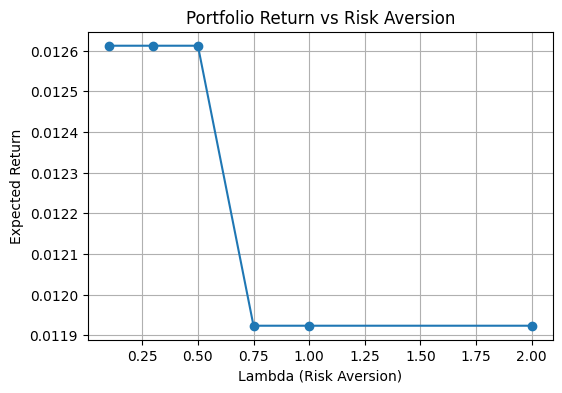

In [32]:
import matplotlib.pyplot as plt

lambda_vals = []
returns = []

for current_lambda in lambda_values:

    row = results_df[
        (results_df["lambda"] == current_lambda) &
        (results_df["beta"] == 1) &
        (results_df["gamma"] == 0.01)
    ].iloc[0]

    lambda_vals.append(current_lambda)

    selected = row["selected_stocks"]

    x = np.array([
        1 if stock in selected else 0
        for stock in stocks
    ])

    returns.append(np.dot(mu, x))

plt.figure(figsize=(6,4))

plt.plot(
    lambda_vals,
    returns,
    marker="o"
)

plt.xlabel("Lambda (Risk Aversion)")
plt.ylabel("Expected Return")
plt.title("Portfolio Return vs Risk Aversion")

plt.grid(True)

plt.show()

### Figure 2: Portfolio Variance vs Risk Aversion (λ)

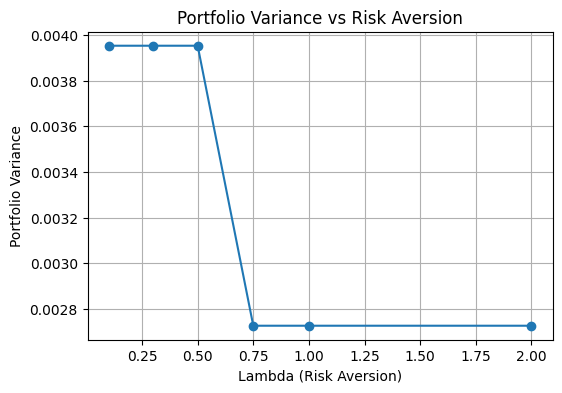

In [33]:
variances = []

for current_lambda in lambda_values:

    row = results_df[
        (results_df["lambda"] == current_lambda) &
        (results_df["beta"] == 1) &
        (results_df["gamma"] == 0.01)
    ].iloc[0]

    selected = row["selected_stocks"]

    x = np.array([
        1 if stock in selected else 0
        for stock in stocks
    ])

    variances.append(
        np.dot(
            x.T,
            np.dot(Sigma, x)
        )
    )

plt.figure(figsize=(6,4))

plt.plot(
    lambda_vals,
    variances,
    marker="o"
)

plt.xlabel("Lambda (Risk Aversion)")
plt.ylabel("Portfolio Variance")
plt.title("Portfolio Variance vs Risk Aversion")

plt.grid(True)

plt.show()

### Observation:
Increasing λ reduces portfolio variance while slightly lowering expected return, reflecting the intended risk-return tradeoff.

### Figure 3: Markowitz vs V3 Portfolio Characteristics

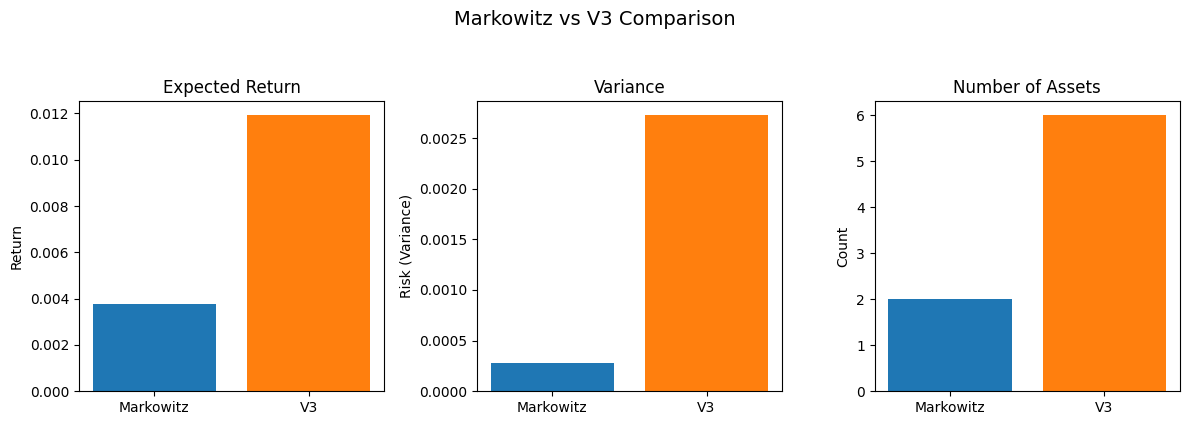

In [34]:
# Data
metrics = ["Expected Return", "Variance", "Number of Assets"]
markowitz_values = [markowitz_expected_return, markowitz_variance, markowitz_number_of_assets]
v3_values = [v3_expected_return, v3_variance, v3_number_of_assets]

# Create 1 row, 3 columns of subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Plot Expected Return
axes[0].bar(["Markowitz", "V3"], [markowitz_values[0], v3_values[0]], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title("Expected Return")
axes[0].set_ylabel("Return")

# Plot Variance
axes[1].bar(["Markowitz", "V3"], [markowitz_values[1], v3_values[1]], color=['#1f77b4', '#ff7f0e'])
axes[1].set_title("Variance")
axes[1].set_ylabel("Risk (Variance)")

# Plot Assets
axes[2].bar(["Markowitz", "V3"], [markowitz_values[2], v3_values[2]], color=['#1f77b4', '#ff7f0e'])
axes[2].set_title("Number of Assets")
axes[2].set_ylabel("Count")

plt.suptitle("Markowitz vs V3 Comparison", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Section 10: TESTING

This comprehensive section is dedicated to rigorously testing and verifying the functionality of the implemented portfolio optimization models across their different versions (V1, V2, and V3). It includes several sub-sections, each designed to validate specific aspects and constraints of the model:

*   **V1 Toy Verification:** Uses a small, brute-forceable dataset to ensure the core energy function and cardinality constraint work correctly.
*   **V2 Sector Constraint Test Ground:** A controlled environment to explicitly demonstrate the effectiveness of the sector capping penalty.
*   **V3 Budget Constraint Test Ground:** Focuses on illustrating how the budget penalty enforces financial limits.

Through these tests, we aim to confirm that each component of the optimization framework behaves as expected under various conditions, building confidence in the model's accuracy and robustness before deployment.

## Conformance Tests

In [36]:
print(mu.shape)
print(Sigma.shape)

(20,)
(20, 20)


In [37]:
print(mu.isna().sum())
print(Sigma.isna().sum().sum())

0
0


## Testing V1: TOY VERIFICATION (5 STOCKS)

This section performs a 'toy' verification using a very small subset of 5 stocks. The primary goal is to exhaustively enumerate all possible portfolios (2^5 = 32 combinations) within this limited scope. By brute-forcing the solution, we can verify that our `energy` function and the general optimization logic correctly identify the optimal portfolio for a known, small problem, ensuring the foundational components work as expected before applying them to the larger dataset.

In [38]:
small_n = 5
small_indices = [0, 5, 10, 15, 18]

In [39]:
mu_small = mu.iloc[small_indices]
Sigma_small = Sigma.iloc[
    small_indices,
    small_indices
]

stocks_small = [stocks[i] for i in small_indices]

### Step 2: Freeze small problem

In [40]:
K_small = 2
lam_Small = 0

### Step 3: Enumerate ALL possibilities

In [41]:
all_portfolios = list(
    itertools.product([0,1], repeat=small_n)
)

### Step 4: Evaluate all portfolios

In [42]:
best_energy = float('inf')
best_portfolio = None

In [43]:
for portfolio in all_portfolios:

    portfolio = np.array(portfolio)

    e = energy(
        portfolio,
        mu_small,
        Sigma_small,
        lam_Small,
        alpha,
        K_small
    )

    if e < best_energy:
        best_energy = e
        best_portfolio = portfolio

### Step 5: Decode selected stocks

In [44]:
selected_indices = np.where(best_portfolio == 1)[0]

In [45]:
selected_stocks = [
    stocks[i] for i in selected_indices
]

### Step 6: Print results

In [46]:
print("TOY VERIFICATION RESULTS")
print("="*40)

print("Selected stocks:")
print(selected_stocks)

print("\nCardinality:")
print(np.sum(best_portfolio))

print("\nEnergy:")
print(best_energy)

TOY VERIFICATION RESULTS
Selected stocks:
['AAPL', 'NVDA']

Cardinality:
2

Energy:
-0.0035139763078199


In [47]:
print("Mean Returns (mu):")
for stock, val in zip(stocks_small, mu_small):
    print(f"{stock}: {val:.6f}")

print("\nDiagonal of Covariance Matrix (risk proxy):")
for stock, val in zip(stocks_small, np.diag(Sigma_small)):
    print(f"{stock}: {val:.6f}")

Mean Returns (mu):
AAPL: 0.001866
JPM: 0.001389
LLY: 0.001648
XOM: 0.000050
CAT: -0.000325

Diagonal of Covariance Matrix (risk proxy):
AAPL: 0.000194
JPM: 0.000194
LLY: 0.000111
XOM: 0.000240
CAT: 0.000194


## Testing V2: Sector Constraint Test

This section serves as a controlled testbed to verify the efficacy of the V2 sector constraint. By utilizing a small, curated subset of stocks and artificially boosting returns for certain sectors, we intentionally create scenarios where the optimizer would naturally over-allocate to a single sector if not for the penalty. This allows us to clearly observe how the `beta` parameter, when activated, successfully forces the portfolio to diversify and adhere to the predefined sector caps, preventing undue concentration.

In [48]:
# ==========================================
# V2 TEST GROUND — FORCE SECTOR CONSTRAINT
# ==========================================

print("\n--- V2 Sector Constraint Test Ground ---")

# Select intentionally tech-heavy subset
test_indices = [0, 1, 2, 4, 5, 10]
# AAPL, MSFT, NVDA, AMZN, JPM, LLY

test_stocks = [stocks[i] for i in test_indices]

# Reduced mu and Sigma
mu_test = mu.iloc[test_indices].copy()

# Artificially boost tech returns
mu_test.iloc[0] = 0.010  # AAPL
mu_test.iloc[1] = 0.011  # MSFT
mu_test.iloc[2] = 0.012  # NVDA
mu_test.iloc[3] = 0.009  # AMZN

# Lower non-tech attractiveness
mu_test.iloc[4] = 0.001  # JPM
mu_test.iloc[5] = 0.001  # LLY

Sigma_test = Sigma.iloc[
    test_indices,
    test_indices
]

# Local sector map for toy experiment
sector_map_test = {
    "Technology": [0, 1, 2, 3],  # AAPL, MSFT, NVDA, AMZN
    "Finance": [4],              # JPM
    "Healthcare": [5]            # LLY
}

# Freeze parameters
K_test = 4
n_test = len(test_indices)
lambda_test = 0.1
sector_cap_test = 2

print(f"Test stocks: {test_stocks}")
print(f"K = {K_test}")
print(f"Sector cap = {sector_cap_test}")

# Compare beta values
test_beta_values = [0, 10]

for beta_test in test_beta_values:

    selected_stocks, min_energy = find_best_portfolio_for_lambda(
        current_lambda=lambda_test,
        current_beta=beta_test,
        mu=mu_test,
        Sigma=Sigma_test,
        alpha=alpha,
        K=K_test,
        n=n_test,
        sector_map=sector_map_test,
        sector_cap=sector_cap_test,
        stock_names=test_stocks,
        prices=prices,          # Added parameter
        budget=budget,          # Added parameter
        current_gamma=0         # Added parameter, set to 0 for V2 test
    )

    # Build x vector
    x_test = np.zeros(n_test)

    for idx, stock in enumerate(test_stocks):
        if stock in selected_stocks:
            x_test[idx] = 1

    # Sector analysis
    sector_counts = get_sector_counts(
        x_test,
        sector_map_test
    )

    violation_status = check_sector_violation(
        sector_counts,
        sector_cap_test
    )

    print("\n" + "="*50)
    print(f"Beta = {beta_test}")
    print("="*50)

    print("Selected Portfolio:")
    print(selected_stocks)

    print("\nEnergy:")
    print(round(min_energy, 6))

    print("\nSector Counts:")
    print(sector_counts)

    print("\nSector Violation:")
    print(violation_status)


--- V2 Sector Constraint Test Ground ---
Test stocks: ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'JPM', 'LLY']
K = 4
Sector cap = 2

Beta = 0
Selected Portfolio:
['AAPL', 'MSFT', 'NVDA', 'AMZN']

Energy:
-0.041839

Sector Counts:
{'Technology': np.float64(4.0), 'Finance': np.float64(0.0), 'Healthcare': np.float64(0.0)}

Sector Violation:
Violated: {'Technology': np.float64(4.0)}

Beta = 10
Selected Portfolio:
['MSFT', 'NVDA', 'JPM', 'LLY']

Energy:
-0.024922

Sector Counts:
{'Technology': np.float64(2.0), 'Finance': np.float64(1.0), 'Healthcare': np.float64(1.0)}

Sector Violation:
None


## Testing V3: Budget Constraint

This section introduces Version 3 (V3) of the portfolio optimization model, which integrates a crucial real-world constraint: the budget. Building upon the cardinality and sector capping features from previous versions, V3 adds a mechanism to penalize portfolios that exceed a predefined spending limit. This allows for a more realistic and financially practical approach to portfolio construction.

### Subsection 1 — Define Budget Parameters (V3)

This subsection defines the key financial parameters for V3: the `prices` of the stocks, the overall `budget` available for the portfolio, and `gamma_values`, which control the strength of the budget penalty during optimization.

In [49]:
# Define a frozen stock price vector
# Using placeholder values for the 20 stocks. In a real scenario, these would come from market data.
prices = np.array([
    150.0, 300.0, 600.0, 120.0, 180.0,  # Technology (AAPL, MSFT, NVDA, GOOGL, AMZN)
    140.0, 200.0, 350.0, 400.0, 100.0,  # Finance (JPM, V, MA, GS, BAC)
    110.0, 170.0, 80.0,  90.0, 130.0,   # Healthcare (LLY, JNJ, MRK, PFE, ABBV)
    70.0,  95.0,  160.0, 250.0, 220.0   # Industrial_Energy (XOM, CVX, GE, CAT, HON)
])

# Define the total budget. Intentionally set so it can sometimes bind for K=6.
# Average price is around $180-$200, so 6 stocks * 180 = $1080. A budget of 1000-1100 will bind.
budget = 1050.0

# Define gamma_values for the sweep, as the budget penalty coefficient
# gamma_values = [0, 0.01, 0.1, 1]
gamma_values = [0, 0.01, 0.1, 1]

print(f"Stock prices defined (sample): {prices[:5]}...")
print(f"Total budget (B): ${budget:.2f}")
print(f"Gamma values for sweep: {gamma_values}")

Stock prices defined (sample): [150. 300. 600. 120. 180.]...
Total budget (B): $1050.00
Gamma values for sweep: [0, 0.01, 0.1, 1]


### Subsection 2 — Budget Penalty Function (V3)

This subsection introduces the `budget_penalty` function, a critical component of V3 that enforces the budget constraint. This function quantifies the 'cost' of exceeding the defined `budget` by calculating a penalty. It takes the selected portfolio (`x`), stock `prices`, the `budget` limit, and the `gamma` penalty coefficient as inputs. The penalty increases quadratically with the amount by which the portfolio's total cost surpasses the budget. By adding this penalty to the overall energy function, the optimizer is incentivized to find portfolios that respect the financial limitations, even if it means sacrificing a small amount of return or taking on slightly more risk.

In [50]:
def budget_penalty(x, prices, budget, gamma):
    """
    Computes the budget constraint penalty for a given portfolio x.

    P_budget(x) = gamma * max(0, sum(w_i * x_i) - B)^2

    Args:
        x (np.array): A binary vector representing the portfolio.
        prices (np.array): A vector of stock prices corresponding to x.
        budget (float): The maximum allowed total cost of the portfolio.
        gamma (float): The budget penalty coefficient.

    Returns:
        float: The computed budget penalty.
    """
    # Calculate the total cost of the selected portfolio
    total_cost = np.dot(x, prices)

    # Calculate the violation: how much the total cost exceeds the budget
    violation = max(0, total_cost - budget)

    # Apply the soft quadratic penalty
    penalty = gamma * (violation**2)

    return penalty

### Subsection 3 — Real Dataset Interpretation Cell (V3)

This subsection provides an in-depth interpretation of the results obtained from applying the budget constraint (V3) to the full dataset. It analyzes how different values of the `gamma` parameter influence portfolio selection, the trade-offs between satisfying the budget and optimizing other objectives (return, risk, cardinality, sector), and situations where the budget constraint may or may not be binding. This interpretation helps in understanding the practical implications of implementing a budget constraint in a portfolio optimization model.

--- Interpretation of Budget Constraint Sweep ---
1. **Impact of Gamma:**
   The `gamma` parameter controls the strength of the budget penalty. When `gamma = 0`, the budget constraint is effectively ignored, and the optimizer will select stocks based purely on return, risk, and sector constraints, potentially leading to portfolios that exceed the budget.
   As `gamma` increases, exceeding the budget becomes more costly in terms of energy. This forces the optimization to favor portfolios that either stay within the budget or violate it by a smaller margin, even if it means selecting stocks with slightly lower returns or higher risk.

2. **Constraint Not Always Binding:**
   It's important to note that even with `gamma > 0`, you might observe that some portfolios do not violate the budget constraint. This does not imply a failure of the constraint or the optimization.
   Instead, it often means that the optimal portfolio (considering returns, risk, cardinality, and sector constraints) naturally falls within the specified budget. In such cases, increasing `gamma` further might not change the portfolio composition, as there's no budget violation to penalize.

3. **Trade-offs:**
   Introducing a budget constraint adds another layer of complexity and trade-offs. A strict budget (high `gamma` or low `budget` value) might prevent the selection of otherwise highly attractive stocks, forcing the optimizer to find a 'good enough' portfolio that respects the financial limitations.

# Stage 3 Direction

Stage 2 prioritised formulation correctness, controlled validation, and exact optimisation through exhaustive enumeration over a tractable search space (( $$\binom{20}{6}$$ $$ = 38,760$$) portfolios). Since exact optimisation remained computationally feasible at this scale, probabilistic or annealing-based methods were intentionally deferred.

Future stages will extend the framework toward a fully compiled QUBO formulation through auxiliary slack-variable encoding for inequality constraints, enabling explicit Q-matrix construction. This would support direct experimentation with probabilistic optimisation methods such as simulated annealing and ORBIT-compatible workflows, particularly for larger asset universes where exhaustive enumeration becomes computationally prohibitive.
